# NeuralForecast Model Integration

This notebook demonstrates how to use [NeuralForecast](https://nixtlaverse.nixtla.io/neuralforecast/docs/) models in Darts through the `NeuralForecastModel` wrapper.

`NeuralForecastModel` converts any of the 30+ NeuralForecast base models into a Darts `TorchForecastingModel`, giving access to the full Darts torch ecosystem: covariates, probabilistic forecasting, optimized historical forecasts/backtesting, model saving/loading, and more.

**Supported models include**: TiDE, PatchTST, KAN, NBEATSx, TSMixer, TimeXer, iTransformer, FEDformer, Autoformer, Informer, and many others.

**Installation**: `NeuralForecastModel` requires the `neuralforecast` package (not included in `darts[all]`):
```bash
pip install "neuralforecast>=3.0.0"
```

For more details, see the [Darts documentation](https://unit8co.github.io/darts/) and the original [NeuralForecast documentation](https://nixtlaverse.nixtla.io/neuralforecast/docs/).

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import logging
import warnings

import pandas as pd

from darts import set_option
from darts.datasets import AirPassengersDataset
from darts.metrics import mae, mape, rmse
from darts.models import NeuralForecastModel, TiDEModel
from darts.utils.likelihood_models import QuantileRegression

warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

set_option("plotting.use_darts_style", True)

config = dict(legend=dict(xanchor="left"))

## 1. Quick Start

Let's start with a simple example using the **TiDE** model on the AirPassengers dataset.

In [3]:
series = AirPassengersDataset().load().astype("float32")

input_chunk_length = 24
output_chunk_length = 12

train, val = series[:-output_chunk_length], series[-output_chunk_length:]

fig = train.plotly(label="train")
fig = val.plotly(label="val", fig=fig)
fig.update_layout(**config)

Using `NeuralForecastModel` is straightforward: set `model` to any NeuralForecast base model name (as a string) or class, and pass model-specific architectural parameters via `model_kwargs`. Everything else (training, covariates, likelihoods) works exactly like any other Darts `TorchForecastingModel`.

<div class="alert alert-success" role="alert">
    Darts will take care of automatically setting non-architectural parameters for you. These parameters <b>will be ignored</b> in <i>model_kwargs</i>:
    <ol>
        <li><b>Input and output parameters</b>: <i>input_size</i>, <i>h</i>, and <i>n_series</i> These are automatically set to match the <i>input_chunk_length</i>, <i>output_chunk_length</i>, and number of target series (components), respectively.
        <li><b>Covariate parameters</b>: <i>futr_exog_list</i>, <i>hist_exog_list</i>, and <i>stat_exog_list</i>. These are inferred directly from the input time series passed to <i>fit()</i>.
        <li><b>Training and PyTorch (Lightning)-related setup</b>: <i>loss</i>, <i>learning_rate</i>, <i>max_steps</i>, etc. are all handled by Darts. You can specify these parameters directly. See the parameter description below for all available options.
    </ol>
</div>

Training: |                                               | 0/? [00:00<?, ?it/s]

Predicting: |                                             | 0/? [00:00<?, ?it/s]

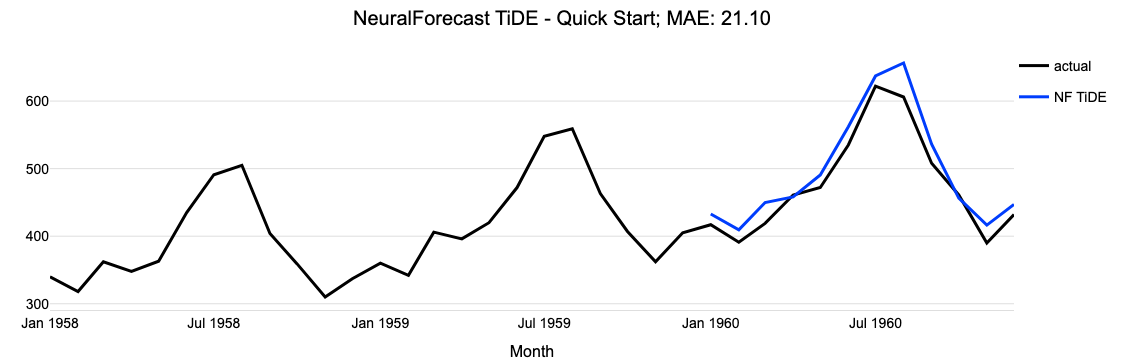

In [4]:
# define parameters shared by all Darts' models
darts_kwargs = dict(
    input_chunk_length=input_chunk_length,  # the model's input window
    output_chunk_length=output_chunk_length,  # the model's output window
    use_reversible_instance_norm=True,  # reversible instance normalization against distribution shift
    n_epochs=50,  # train the model for 50 epochs
    random_state=42,
)

model_nf = NeuralForecastModel(
    model="TiDE",
    model_kwargs={
        "hidden_size": 128,
        "decoder_output_dim": 16,
        "dropout": 0.1,
        "layernorm": False,
    },
    **darts_kwargs,
)

# train and predict
model_nf.fit(train)
pred = model_nf.predict(n=output_chunk_length, series=train)

# plot
fig = series[-3 * output_chunk_length :].plotly(label="actual")
fig = pred.plotly(label="NF TiDE", fig=fig)
fig.update_layout(
    title=f"NeuralForecast TiDE - Quick Start; MAE: {mae(val, pred):.2f}", **config
)

## 2. Comparison: Darts TiDE vs NeuralForecast TiDE

Since Darts has its own native TiDE implementation, let's compare it side by side with the NeuralForecast version. This helps validate the integration and shows that NeuralForecast models can achieve comparable results.

Training: |                                               | 0/? [00:00<?, ?it/s]

Predicting: |                                             | 0/? [00:00<?, ?it/s]

Darts TiDE - MAE: 15.75


Training: |                                               | 0/? [00:00<?, ?it/s]

Predicting: |                                             | 0/? [00:00<?, ?it/s]

NF TiDE - MAE: 21.10


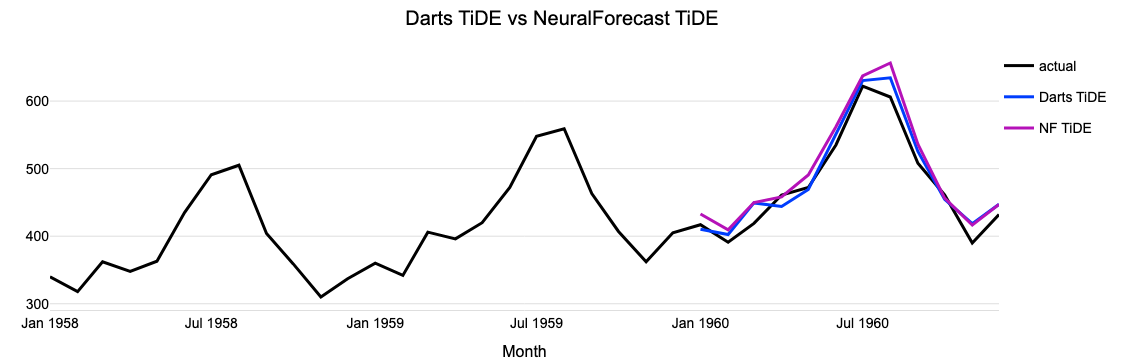

In [5]:
model_nf = model_nf.untrained_model()  # get a fresh instance of the nf model
model_darts = TiDEModel(**darts_kwargs)

fig = series[-3 * output_chunk_length :].plotly(label="actual")

for model_i, name in [(model_darts, "Darts TiDE"), (model_nf, "NF TiDE")]:
    model_i.fit(train)
    forecast = model_i.predict(n=output_chunk_length, series=train)
    forecast.plotly(label=name, fig=fig)
    print(f"{name} - MAE: {mae(val, forecast):.2f}")

fig.update_layout(title="Darts TiDE vs NeuralForecast TiDE", **config)

## 3. Probabilistic Forecasting

`NeuralForecastModel` supports probabilistic forecasting through **Darts' likelihood models**. This works with **any** NeuralForecast base model.

Let's use **Quantile Regression** with a **KAN** (Kolmogorov-Arnold Network) model — a model only available through NeuralForecast.

<div class="alert alert-success" role="alert">
  Darts offers many other likelihood models such as Gaussian, Poisson, Laplace and more. You can find a complete list  
  <a href="https://unit8co.github.io/darts/generated_api/darts.utils.likelihood_models.torch.html">here</a>.
</div>

Training: |                                               | 0/? [00:00<?, ?it/s]

Predicting: |                                             | 0/? [00:00<?, ?it/s]

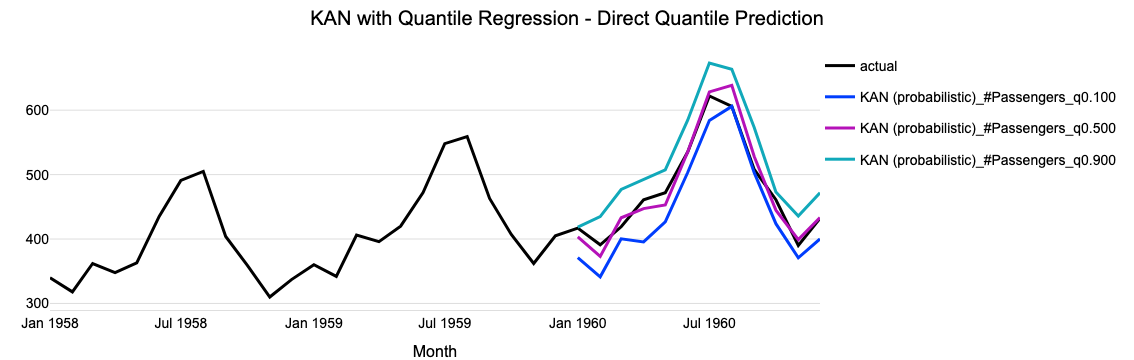

In [6]:
# KAN model that forecasts expected quantiles [0.1, 0.5, 0.9]
model_kan = NeuralForecastModel(
    model="KAN",
    likelihood=QuantileRegression(quantiles=[0.1, 0.5, 0.9]),
    **darts_kwargs,
)

# fit and predict
model_kan.fit(train)
pred_prob = model_kan.predict(
    n=output_chunk_length,
    series=train,
    predict_likelihood_parameters=True,  # predict quantiles directly
)

# plot
fig = series[-3 * output_chunk_length :].plotly(label="actual")
fig = pred_prob.plotly(label="KAN (probabilistic)", fig=fig)
fig.update_layout(
    title="KAN with Quantile Regression - Direct Quantile Prediction",
    legend=dict(xanchor="left"),
)

We can also generate **sampled predictions**. This is especially useful when performing auto-regression (when horizon > output_chunk_length), as it esentially is a **Monte Carlo Simulation** of the different sample paths.

Predicting: |                                             | 0/? [00:00<?, ?it/s]

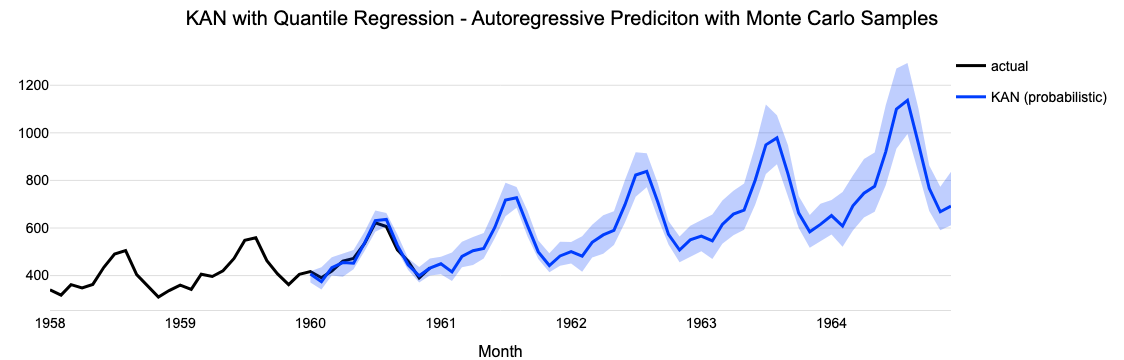

In [7]:
pred_prob = model_kan.predict(
    n=5 * output_chunk_length,
    series=train,
    num_samples=200,  # sampled prediction
)

# plot
fig = series[-3 * output_chunk_length :].plotly(label="actual")
fig = pred_prob.plotly(label="KAN (probabilistic)", fig=fig)
fig.update_layout(
    title="KAN with Quantile Regression - Autoregressive Prediciton with Monte Carlo Samples",
    legend=dict(xanchor="left"),
)

## 4. Forecasting Using Covariates

Many NeuralForecast models support covariates. The wrapper automatically detects which covariate types are supported by the chosen base model and wires them into the Darts pipeline. There is no need to specify `futr_exog_list`, `hist_exog_list`, and `stat_exog_list`. These are inferred directly from the input time series passed to `NeuralForecastModel.fit()`.

Let's generate some future covariates from calendar attributes of the AirPassengers series and use a **TSMixerx** model.

<div class="alert alert-success" role="alert">
  For simplicity, you can also let the model generate these features for you with the `add_encoders` parameter. More info in the 
  <a href="https://unit8co.github.io/darts/quickstart/00-quickstart.html#Encoders:-using-covariates-for-free">quickstart</a>.
</div>

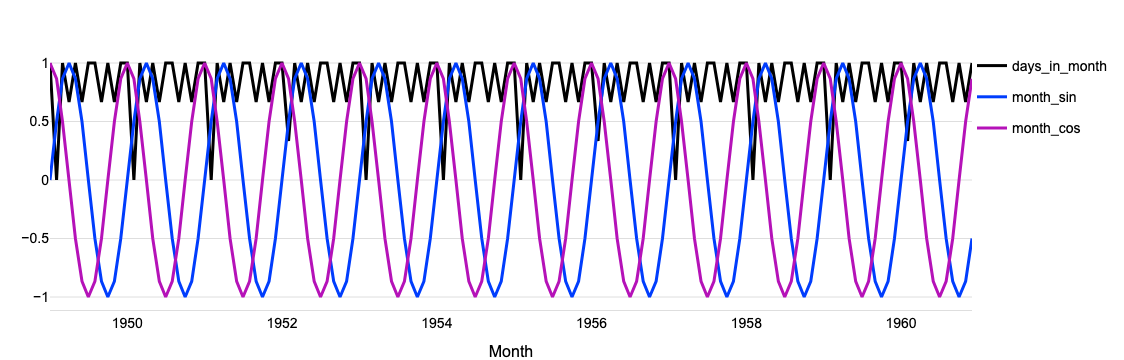

In [8]:
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries

# generate feature: number of days per month, and apply a MinMax scaler to scale all values into the range (0,1)
future_covariates = datetime_attribute_timeseries(series, attribute="days_in_month")
future_covariates = Scaler().fit_transform(future_covariates)

# let's also add a cyclic encoding (sin + cosine wave) of the value the month
future_covariates = future_covariates.add_datetime_attribute(
    "month", cyclic=True
).astype("float32")

# finally, apply a MinMax scaler to scale all values into the range (0,1)
fig = future_covariates.plotly()
fig.update_layout(**config)

Training: |                                               | 0/? [00:00<?, ?it/s]

Predicting: |                                             | 0/? [00:00<?, ?it/s]

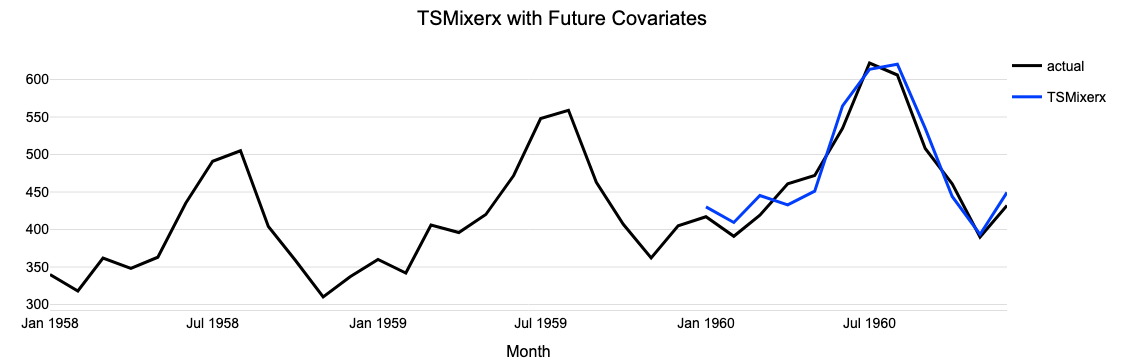

In [9]:
# this time we use TSMixerx, a model that supports future covariates
model_cov = NeuralForecastModel(model="TSMixerx", **darts_kwargs)

# fit and predict
model_cov.fit(train, future_covariates=future_covariates)
forecast_cov = model_cov.predict(
    n=output_chunk_length,
    series=train,
    future_covariates=future_covariates,
)

# plot
fig = series[-3 * output_chunk_length :].plotly(label="actual")
fig = forecast_cov.plotly(label="TSMixerx", fig=fig)
fig.update_layout(title="TSMixerx with Future Covariates", **config)

## 5. Historical Forecasts / Backtesting

Since `NeuralForecastModel` is a Darts `TorchForecastingModel`, it has access to all other Darts functionality. For **more robust evaluation**, we should make use of Darts' **optimized historical forecast & backtesting** routine (very similar to NeuralForecasts cross validation).

Training: |                                               | 0/? [00:00<?, ?it/s]

Predicting: |                                             | 0/? [00:00<?, ?it/s]

Generating TimeSeries:   0%|          | 0/3 [00:00<?, ?it/s]

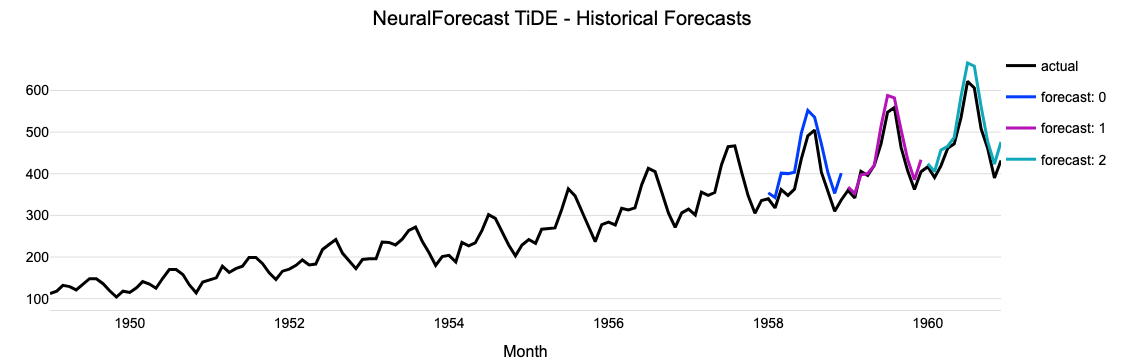

In [10]:
# get a fresh TiDE instance and train it on everything except the last 36 points
model_backtest = model_nf.untrained_model()
model_backtest.fit(series[:-36])

# generate forecasts sequentially over the last 36 points
historical_forecasts = model_backtest.historical_forecasts(
    series=series,
    start=-36,
    forecast_horizon=output_chunk_length,
    stride=output_chunk_length,  # move 12 steps ahead after each forecast
    retrain=False,  # no re-training, only apply pre-trained model
    verbose=True,
    last_points_only=False,
)

fig = series.plotly(label="actual")
for idx, forecast in enumerate(historical_forecasts):
    fig = forecast.plotly(label=f"forecast: {idx}", fig=fig)
fig.update_layout(title="NeuralForecast TiDE - Historical Forecasts", **config)

And now we can compute any number of metrics on the historical forecasts (backtesting).

In [11]:
metrics = model_backtest.backtest(
    series=series,
    historical_forecasts=historical_forecasts,
    last_points_only=False,
    metric=[mae, rmse, mape],
)

pd.Series(metrics, index=["MAE", "RMSE", "MAPE"])

MAE     32.725391
RMSE    36.644840
MAPE     7.757057
dtype: float32

## 6. Multivariate Forecasting

Multivariate forecasting is supported by all base models. Simply pass a multivariate time series as `series` to `fit()` and `predict()`.

<div class="alert alert-success" role="alert">
  For <b>univariate base models</b>, multivariate forecasting is achieved by folding the target components into the batch dimension and repeating the covariates for each target component accordingly. This translates to <b>global training</b> and forecasting <b>on multiple univariate series</b>.
</div>


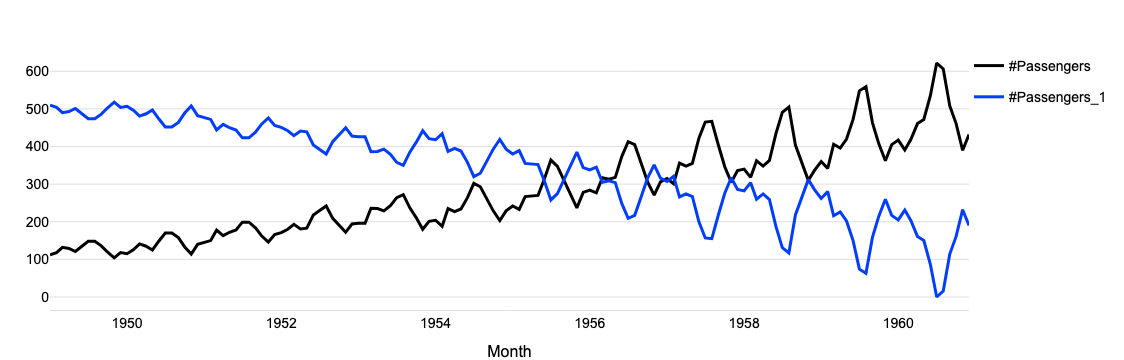

In [12]:
# generate a multivariate series
series_multivar = series.stack(series * -1 + series.max(axis=0))
fig = series_multivar.plotly()
fig.update_layout(**config)

Training: |                                               | 0/? [00:00<?, ?it/s]

Predicting: |                                             | 0/? [00:00<?, ?it/s]

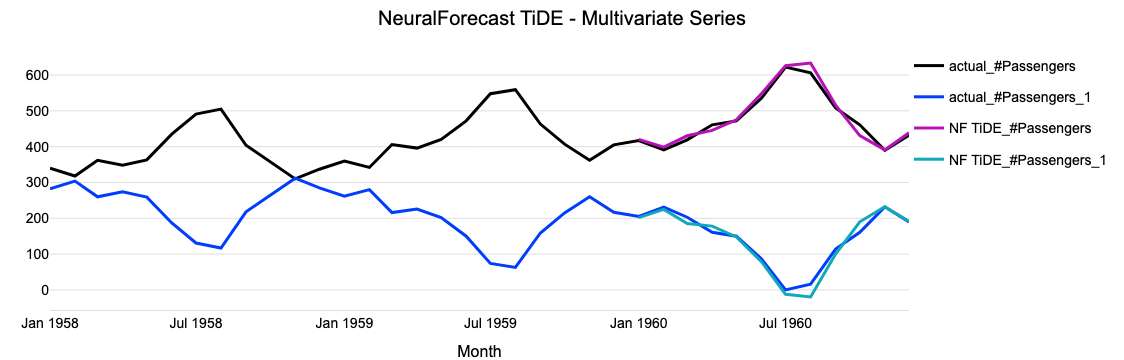

In [13]:
# get a fresh model instance
model_nf = model_nf.untrained_model()

# fit and predict
pred = model_nf.fit(series_multivar[:-12]).predict(n=output_chunk_length)

# plot
fig = series_multivar[-3 * output_chunk_length :].plotly(label="actual")
fig = pred.plotly(label="NF TiDE", fig=fig)
fig.update_layout(title="NeuralForecast TiDE - Multivariate Series", **config)

## 6. Multiple Series Forecasting

Multiple time series is supported by all base models. Simply pass a sequence of uni- or multivariate time series as ``series`` to `fit()` and `predict()`.

Training: |                                               | 0/? [00:00<?, ?it/s]

Predicting: |                                             | 0/? [00:00<?, ?it/s]

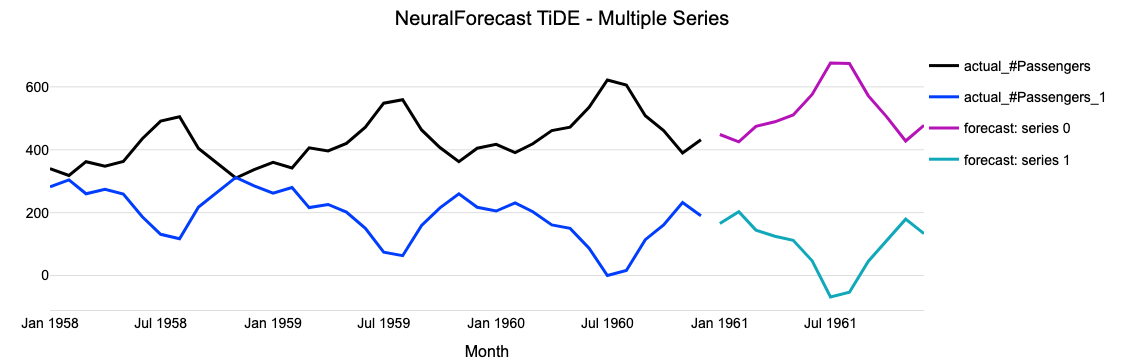

In [14]:
# split the multivariate series into multiple univariate series
series_multiple = [series_multivar["#Passengers"], series_multivar["#Passengers_1"]]

# get a fresh model instance
model_nf = model_nf.untrained_model()

# fit and predict
forecasts = model_nf.fit(series_multiple).predict(
    n=output_chunk_length, series=series_multiple
)

# plot
fig = series_multivar[-3 * output_chunk_length :].plotly(label="actual")
for idx, forecast in enumerate(forecasts):
    fig = forecast.plotly(label=f"forecast: series {idx}", fig=fig)
fig.update_layout(title="NeuralForecast TiDE - Multiple Series", **config)

## Summary

The `NeuralForecastModel` wrapper makes it easy to:

- **Access 30+ neural forecasting architectures** through a unified interface.
- **Use all Darts torch features**: Uni- & multivariate forecasting, multiple series forecasting, probabilistic forecasting, covariates (past, future, static), optimized backtesting, model saving/loading, encoders, and more.
- **Quickly experiment** with different architectures by simply changing the `model` parameter.

### Limitations

- **Recurrent models** (GRU, LSTM, RNN, DeepAR) are not supported — Darts provides native implementations.
- The core `NeuralForecast` class and automatic models (e.g. `AutoInformer`) are not supported.
- `neuralforecast>=3.0.0` must be installed separately (`pip install neuralforecast`).

For more information, see the [NeuralForecastModel API reference](https://unit8co.github.io/darts/generated_api/darts.models.forecasting.nf_model.html).